In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import logging
import os
import sys
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors

In [2]:
def accuracy_metric(data, cloud_corrected, time_sel):
    truth_eval = xr.open_dataset(data_path)['truth'].sel(time=time_sel).values
    pred_eval  = xr.open_dataset(cloud_corrected)['snow_mask'].sel(time=time_sel).values
    mask_eval  = xr.open_dataset(data_path)['synthetic_cloud_mask'].sel(time=time_sel).values.astype(bool)
    
    valid = mask_eval & np.isfinite(pred_eval)
    
    accuracy = np.mean(truth_eval[valid] == pred_eval[valid])
    return accuracy

# ----------------------------
# Convert NaN -> class 2 (cloud)
# ----------------------------
def nan_to_class2(da):
    return xr.where(np.isnan(da), 2, da).astype(float)

def process_da(data_path, corrected_path, time_sel):

    
    data = xr.open_dataset(data_path)
    cloud_corrected = xr.open_dataset(corrected_path)
        
    truth = data['truth'].sel(time=time_sel)
    cloudy = data['snow_mask'].sel(time=time_sel)
    corrected = cloud_corrected['snow_mask'].sel(time=time_sel)
    
   
    lon = data['lon'].values
    lat = data['lat'].values
    extent = [lon.min(), lon.max(), lat.min(), lat.max()]
    
    truth_p = nan_to_class2(truth)
    cloudy_p = nan_to_class2(cloudy)
    corrected_p = nan_to_class2(corrected)
    return  truth_p, cloudy_p, corrected_p, extent


time1 = '2009-10-17'

time2 = '2010-04-08'

data_path = '../data/nstf_test_data.nc'

corrected_path1 = '../data/validation_extra2010.nc'
corrected_path2 = '../data/validation2010.nc'

truth_1, cloudy_1, corrected_1, extent = process_da(data_path, corrected_path1, time1)
truth_2, cloudy_2, corrected_2, extent = process_da(data_path, corrected_path2, time2)
acc1 = accuracy_metric(data_path, corrected_path1, time1) # add acc to plot
acc2 = accuracy_metric(data_path, corrected_path2, time2) # add acc to plot


/tmp/ipykernel_53518/728305946.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cividis = cm.get_cmap("viridis")


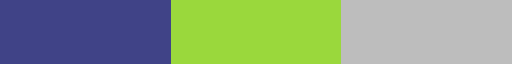

In [3]:
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.cm as cm
# ----------------------------
cividis = cm.get_cmap("viridis")
cmap = ListedColormap([cividis(0.2), cividis(0.85), "#BDBDBD"])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

cmap

In [4]:
data = xr.open_dataset(data_path)
lon = data['lon'].values
lat = data['lat'].values
diff = .45

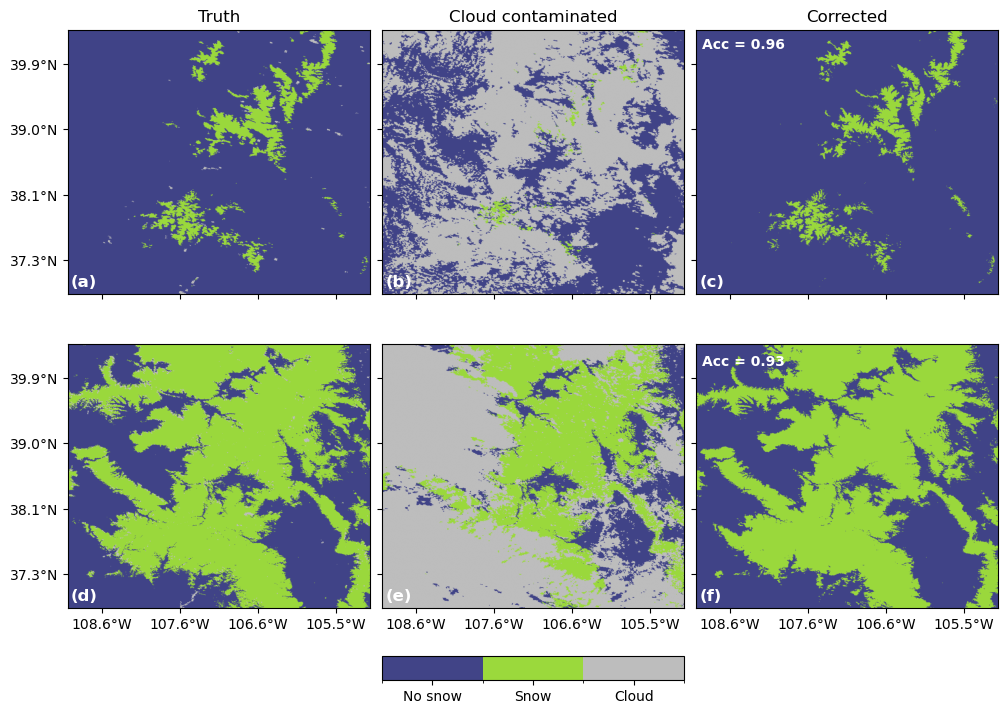

In [5]:

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.subplots_adjust(wspace=0.04, hspace=0.04)
panels = [
    (truth_1, "Truth"),
    (cloudy_1, "Cloud contaminated"),
    (corrected_1, "Corrected"),
    (truth_2, "Truth"),
    (cloudy_2, "Cloud contaminated"),
    (corrected_2, "Corrected"),
]

index = ['(a)','(b)','(c)','(d)','(e)','(f)']

for i, (ax, (arr, title),ind) in enumerate(zip(axes.flatten(), panels,index)):
    im = ax.imshow(arr.values, cmap=cmap, norm=norm, extent=extent, origin='upper')
    ax.text(0.01, 0.03, ind, transform=ax.transAxes, fontsize=12, color='white', weight='bold')
    if i <3:
        ax.set_title(title)

# ---- Add accuracy annotations ----
axes[0,2].text(
    0.02, 0.93,
    f"Acc = {acc1:.2f}",
    transform=axes[0,2].transAxes,
    fontsize=10,
    color = 'white',
    weight = 'bold'
    
)

axes[1,2].text(
    0.02, 0.92,
    f"Acc = {acc2:.2f}",
    transform=axes[1,2].transAxes,
    fontsize=10,
    color = 'white',
    weight = 'bold'
    
)

for i, ax in enumerate(axes.flat):
    ax.set_xticks(np.linspace(lon.min() + diff, lon.max() - diff, 4))
    ax.set_yticks(np.linspace(lat.min() + diff, lat.max() - diff, 4))

    lon_ticks = ax.get_xticks()
    lat_ticks = ax.get_yticks()
    
    lon_labels = [f'{abs(lon):.1f}°{"W" if lon < 0 else "E"}' for lon in lon_ticks]
    lat_labels = [f'{abs(lat):.1f}°{"S" if lat < 0 else "N"}' for lat in lat_ticks]
    
    ax.set_xticklabels(lon_labels)
    ax.set_yticklabels(lat_labels)


    if i not in [0,3]:
        ax.set_yticklabels([''] * len(ax.get_yticks()))

    if i < 3: 
        ax.set_xticklabels([''] * len(ax.get_xticks()))

# ---- Horizontal colorbar centered below panel 5 ----
# position of middle-bottom axis
bbox = axes[1,1].get_position()

cbar_ax = fig.add_axes([
    bbox.x0,          # left
    bbox.y0 -0.09,   # vertical offset below panel
    bbox.width,       # same width as panel
    0.03              # height
])

cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_ticks([0, 1, 2])
cbar.set_ticklabels(["No snow", "Snow", "Cloud"])
plt.savefig('a.pdf')
plt.show()
